In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.style.use("default")
sns.set_theme(style="whitegrid")

## Report Directories

In [2]:
REPORT_DIR = "../../src/reports/environmental_analytics"
IMAGE_DIR = "../../src/reports/environmental_analytics/images"

Path(REPORT_DIR).mkdir(
    parents=True,
    exist_ok=True
)

Path(IMAGE_DIR).mkdir(
    parents=True,
    exist_ok=True
)

## Load Dataset

In [3]:
df = pd.read_parquet(
    "../../data/curated/environmental_master.parquet"
)

print(df.shape)
df.head()

(508116, 20)


,datetime,station_id,station_name,district,latitude,longitude,aqi,pm25,pm10,humidity,temperature,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2022-01-01 21:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,123,66.79,109.32,71.50,18.09,15.6,87,13.4,0.0,1018.4,48,7.6,315,11.2
1,2022-01-01 21:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,193,87.98,173.04,72.72,18.48,16.2,81,13.0,0.0,1018.6,18,7.4,331,12.6
2,2022-01-01 21:00:00,WB015,Sarsuna College,Kolkata,22.481270,88.284554,185,85.59,194.13,73.95,18.51,16.8,78,12.9,0.0,1018.7,57,7.4,317,13.3
3,2022-01-01 22:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,145,73.56,156.15,75.74,17.73,15.4,88,13.5,0.0,1018.3,100,7.4,321,11.2
4,2022-01-01 22:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,231,99.37,168.51,75.08,18.05,15.6,85,13.1,0.0,1018.4,74,7.1,330,11.2


## Dataset Overview

In [4]:
overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Stations",
        "Start Date",
        "End Date"
    ],

    "Value": [
        len(df),
        len(df.columns),
        df["station_id"].nunique(),
        df["datetime"].min(),
        df["datetime"].max()
    ]
})

overview

,Metric,Value
0,Rows,508116
1,Columns,20
2,Stations,17
3,Start Date,2022-01-01 21:00:00
4,End Date,2026-05-30 21:00:00


In [5]:
overview.to_csv(
    f"{REPORT_DIR}/dataset_overview.csv",
    index=False
)

# Section A
# AQI Distribution Analysis
---

In [6]:
df["aqi"].describe()

count    508116.000000
mean         91.014473
std          63.770344
min           1.000000
25%          48.000000
50%          73.000000
75%         110.000000
max         697.000000
Name: aqi, dtype: float64

In [7]:
df["aqi"].describe().to_csv(
    f"{REPORT_DIR}/aqi_summary_statistics.csv",
    index=False
)

## Histogram

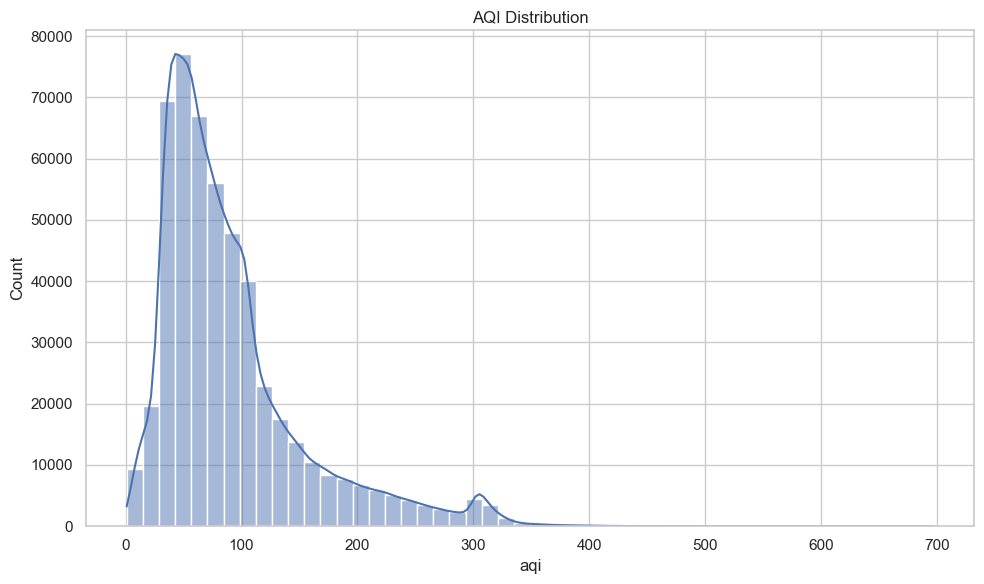

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["aqi"],
    bins=50,
    kde=True
)

plt.title("AQI Distribution")

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/aqi_distribution.png",
    dpi=300
)

plt.show()

# Section B
# Temporal Analysis
---

## Create Time Features

In [9]:
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["hour"] = df["datetime"].dt.hour

## Yearly AQI

In [10]:
yearly_aqi = (
    df.groupby("year")["aqi"]
    .mean()
    .reset_index()
)

yearly_aqi.to_csv(
    f"{REPORT_DIR}/yearly_aqi.csv", 
    index=False
)

print("Saved yearly_aqi.csv")

Saved yearly_aqi.csv


## Plot Yearly AQI Trend

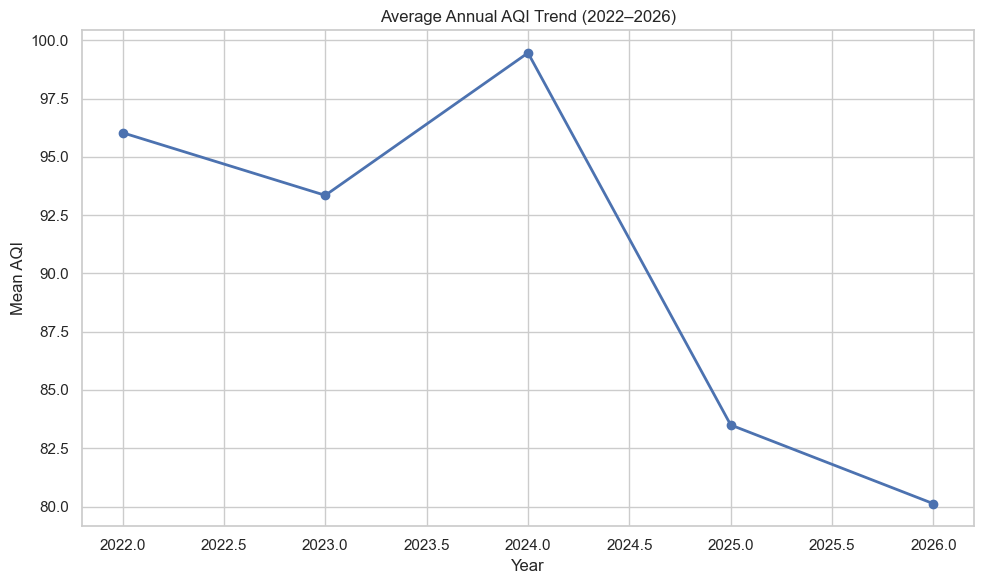

In [12]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_aqi["year"],
    yearly_aqi["aqi"],
    marker="o",
    linewidth=2
)

plt.title(
    "Average Annual AQI Trend (2022–2026)"
)

plt.xlabel("Year")

plt.ylabel("Mean AQI")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/aqi_yearly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Monthly AQI Statistics

In [13]:
monthly_aqi = (
    df.groupby("month")["aqi"]
    .mean()
    .reset_index()
)

monthly_aqi.columns = [
    "month",
    "mean_aqi"
]

monthly_aqi.to_csv(
    f"{REPORT_DIR}/monthly_aqi.csv",
    index=False
)

print("Saved monthly_aqi.csv")

Saved monthly_aqi.csv


## Plot Monthly AQI Trend

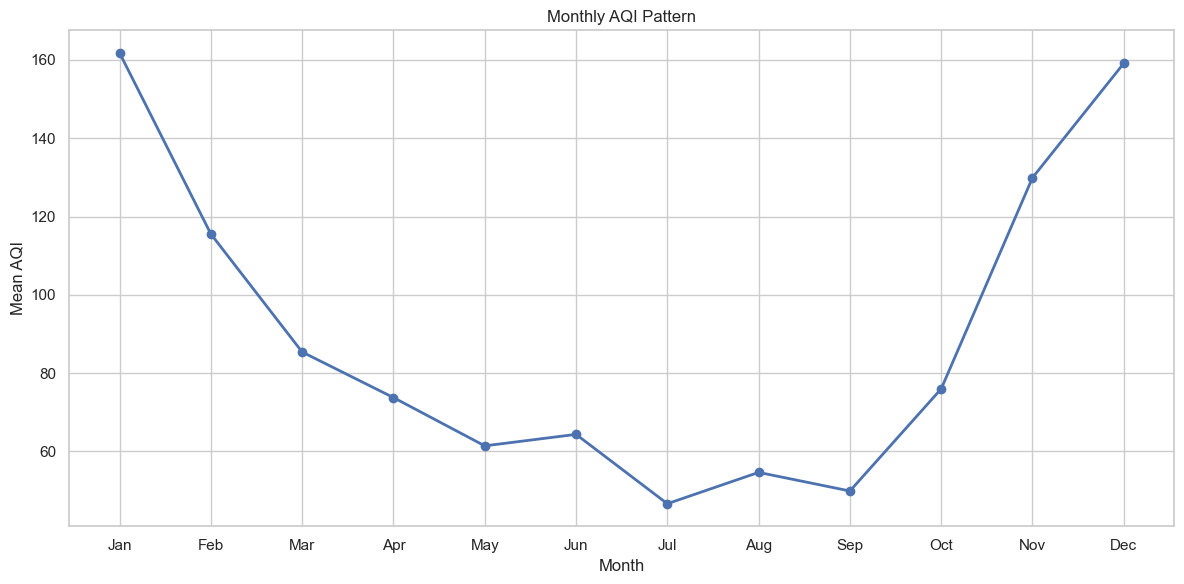

In [14]:
month_names = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec"
]

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_aqi["month"],
    monthly_aqi["mean_aqi"],
    marker="o",
    linewidth=2
)

plt.xticks(
    range(1, 13),
    month_names
)

plt.title(
    "Monthly AQI Pattern"
)

plt.xlabel("Month")

plt.ylabel("Mean AQI")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/aqi_monthly_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Hourly AQI Statistics

In [15]:
hourly_aqi = (
    df.groupby("hour")["aqi"]
    .mean()
    .reset_index()
)

hourly_aqi.columns = [
    "hour",
    "mean_aqi"
]

hourly_aqi.to_csv(
    f"{REPORT_DIR}/hourly_aqi.csv",
    index=False
)

print("Saved hourly_aqi.csv")

Saved hourly_aqi.csv


## Plot Hourly AQI Pattern

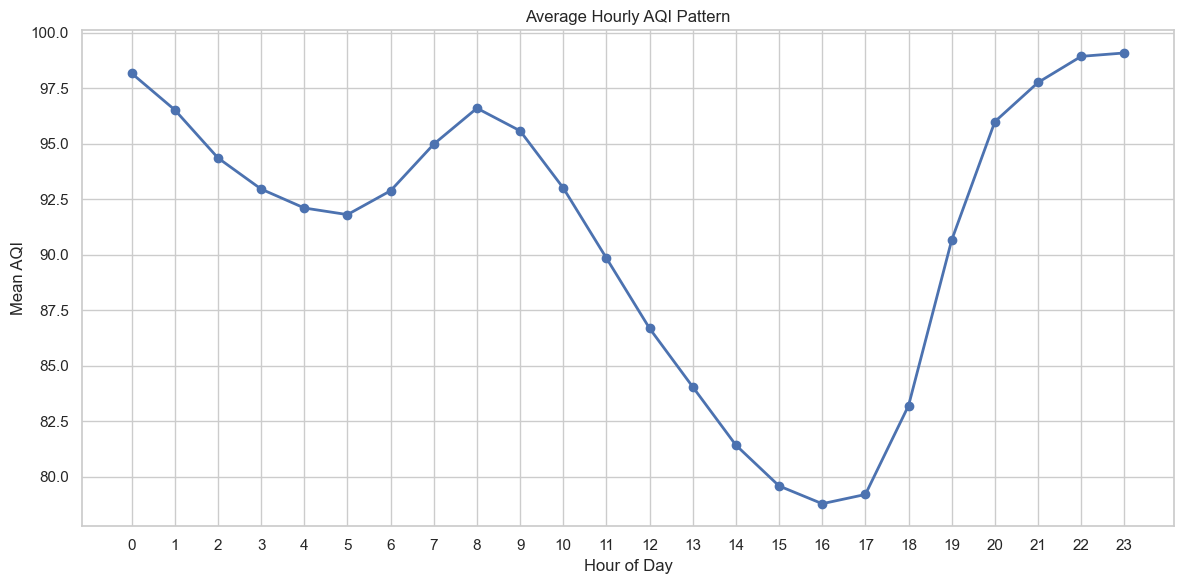

In [16]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_aqi["hour"],
    hourly_aqi["mean_aqi"],
    marker="o",
    linewidth=2
)

plt.xticks(
    range(0, 24)
)

plt.title(
    "Average Hourly AQI Pattern"
)

plt.xlabel("Hour of Day")

plt.ylabel("Mean AQI")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/aqi_hourly_pattern.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Daily AQI Trend

In [17]:
daily_aqi = (
    df.groupby(
        df["datetime"].dt.date
    )["aqi"]
    .mean()
    .reset_index()
)

daily_aqi.columns = [
    "date",
    "mean_aqi"
]

daily_aqi.head()

,date,mean_aqi
0,2022-01-01,187.888889
1,2022-01-02,229.069444
2,2022-01-03,206.750000
3,2022-01-04,252.472222
4,2022-01-05,270.130435


In [18]:

daily_aqi.to_csv(
    f"{REPORT_DIR}/daily_aqi.csv",
    index=False
)

print("Saved daily_aqi.csv")

Saved daily_aqi.csv


## Daily AQI Time Series Plot

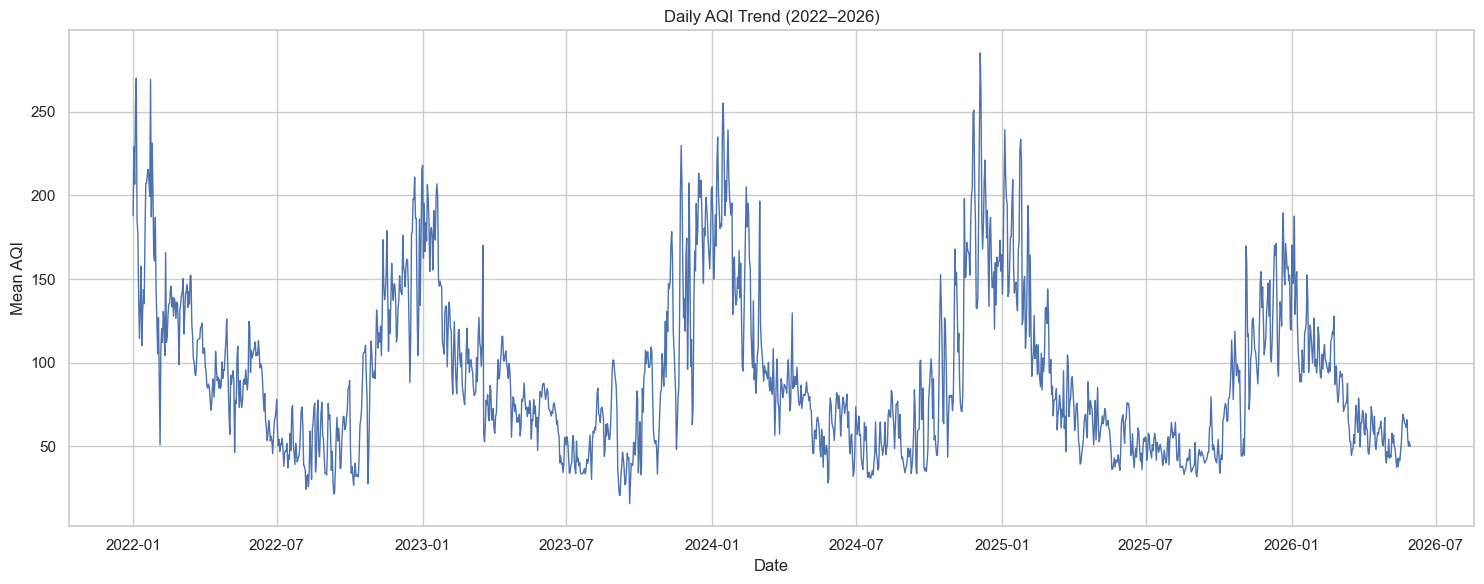

In [19]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_aqi["date"],
    daily_aqi["mean_aqi"],
    linewidth=1
)

plt.title(
    "Daily AQI Trend (2022–2026)"
)

plt.xlabel("Date")

plt.ylabel("Mean AQI")

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/daily_aqi_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Section C 
# Seasonal Analysis
---

## Define Seasons

In [20]:
def get_season(month):

    if month in [3, 4, 5]:
        return "Summer"

    elif month in [6, 7, 8, 9]:
        return "Monsoon"

    else:
        return "Winter"

## Create Season Column

In [21]:
df["season"] = (
    df["month"]
    .apply(get_season)
)

df["season"].value_counts()

season
Winter     213181
Monsoon    153183
Summer     141752
Name: count, dtype: int64

## Seasonal AQI Statistics

In [22]:
seasonal_stats = (
    df.groupby("season")["aqi"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std"
    ])
    .round(2)
)

seasonal_stats.to_csv(
    f"{REPORT_DIR}/seasonal_statistics.csv"
)

print("Saved seasonal_statistics.csv")

Saved seasonal_statistics.csv


## Seasonal AQI Bar Plot

In [23]:
seasonal_mean = (
    df.groupby("season")["aqi"]
    .mean()
    .reset_index()
)

seasonal_mean

,season,aqi
0,Monsoon,53.792947
1,Summer,73.352757
2,Winter,129.504248


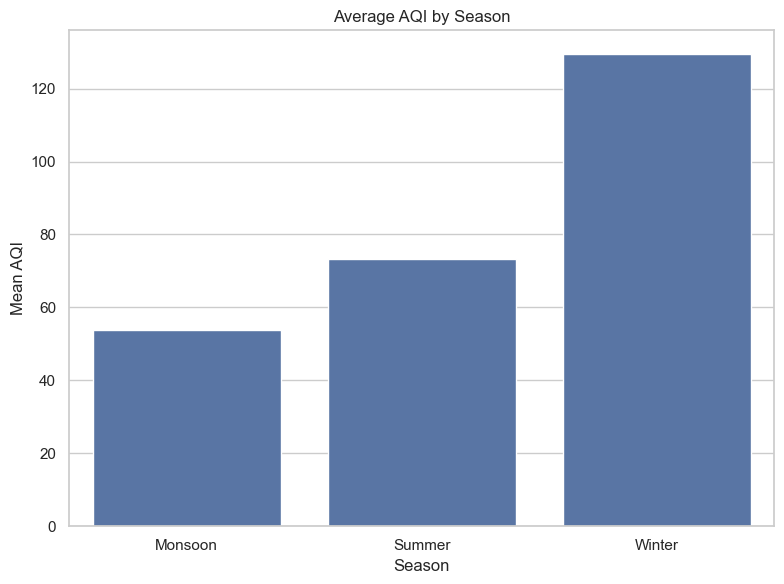

In [24]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=seasonal_mean,
    x="season",
    y="aqi"
)

plt.title(
    "Average AQI by Season"
)

plt.xlabel("Season")

plt.ylabel("Mean AQI")

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/seasonal_mean_aqi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Seasonal AQI Boxplot

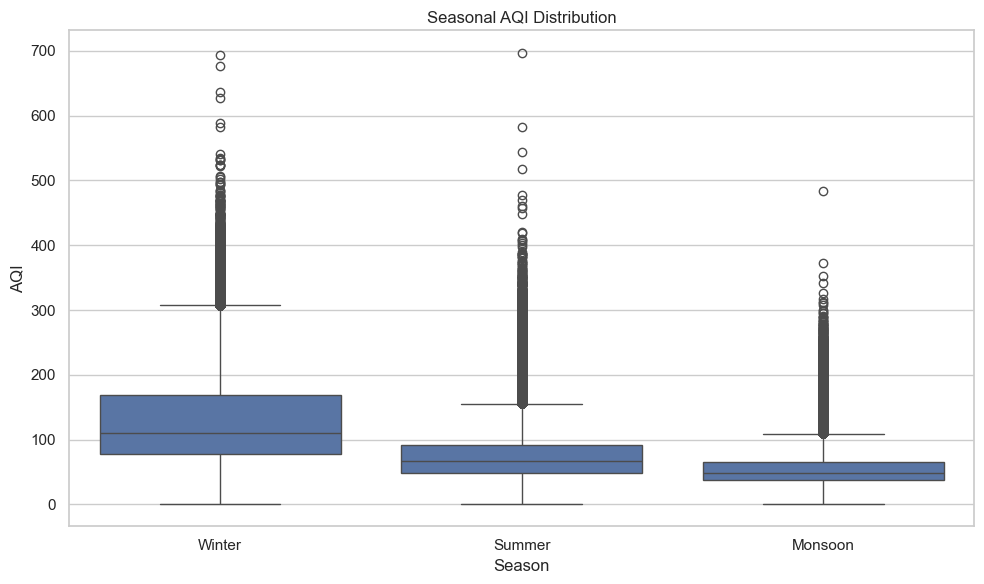

In [25]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="season",
    y="aqi"
)

plt.title(
    "Seasonal AQI Distribution"
)

plt.xlabel("Season")

plt.ylabel("AQI")

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/seasonal_aqi_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Monthly AQI Heatmap

In [26]:
heatmap_data = (
    df.pivot_table(
        values="aqi",
        index="year",
        columns="month",
        aggfunc="mean"
    )
)

heatmap_data

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2022,182.807575,124.401757,123.451708,91.762694,87.383408,80.512646,50.773502,51.012298,54.619143,67.530795,129.918440,156.931122
2023,166.172288,103.449959,89.048516,86.108806,70.627172,66.531599,41.848696,66.649972,44.760738,77.062140,130.455643,164.690076
2024,191.295074,135.819830,93.115976,86.149167,58.131376,64.546561,46.616177,58.057486,53.982564,83.467586,149.775090,175.434567
2025,169.633492,117.443840,79.068951,63.308254,54.605332,55.161251,48.452804,44.725388,47.308453,74.165534,112.094394,140.680971
2026,120.039186,101.653453,69.436638,57.668073,51.670196,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Plot Heatmap

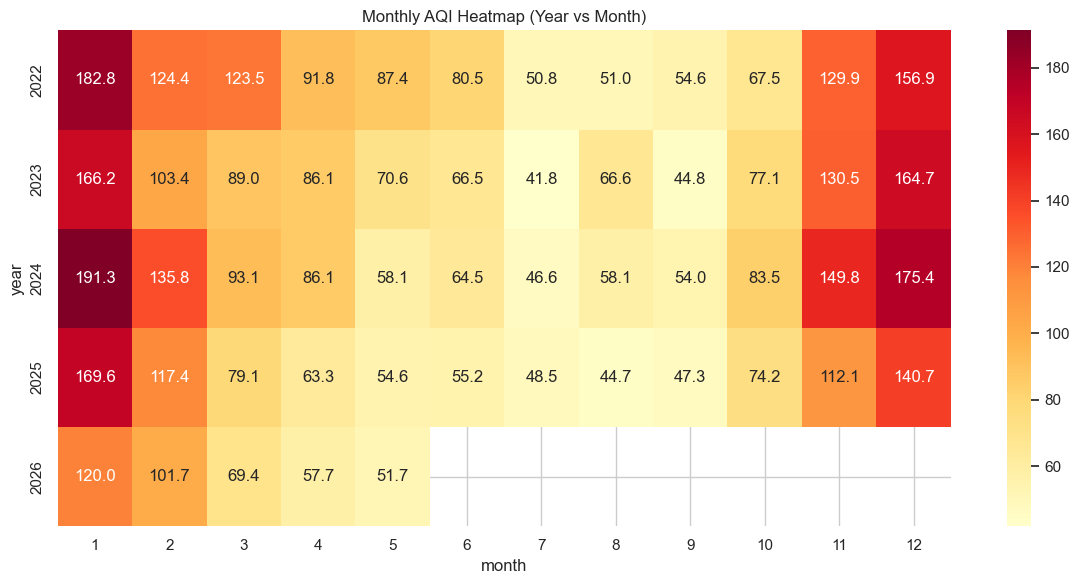

In [27]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title(
    "Monthly AQI Heatmap (Year vs Month)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/monthly_aqi_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## PM2.5 Seasonal Statistics

In [28]:
seasonal_pm25 = (
    df.groupby("season")["pm25"]
    .agg([
        "mean",
        "median",
        "max",
        "std"
    ])
    .round(2)
)

seasonal_pm25.to_csv(
    f"{REPORT_DIR}/seasonal_pm25_statistics.csv"
)

print("Saved seasonal_pm25_statistics.csv")

Saved seasonal_pm25_statistics.csv


## PM2.5 Seasonal Boxplot

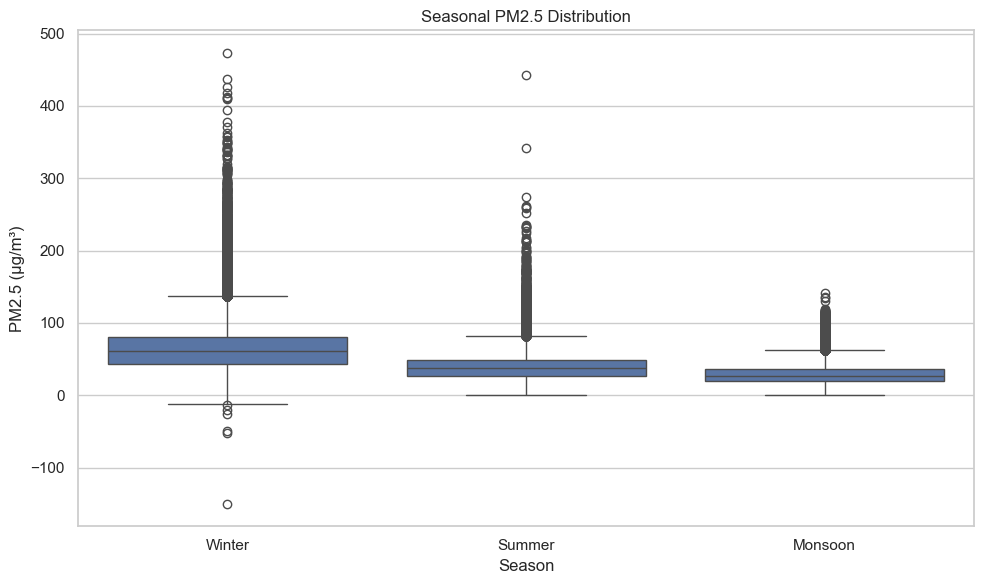

In [29]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="season",
    y="pm25"
)

plt.title(
    "Seasonal PM2.5 Distribution"
)

plt.xlabel("Season")

plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/seasonal_pm25_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Section D
# Station Ranking & Pollution Analysis
---

## Station-wise AQI Statistics

In [30]:
station_stats = (
    df.groupby(
        ["station_id", "station_name"]
    )["aqi"]
    .agg([
        "count",
        "mean",
        "median",
        "min",
        "max",
        "std"
    ])
    .round(2)
    .reset_index()
)

station_stats.head()

,station_id,station_name,count,mean,median,min,max,std
0,WB001,Avidipta Housing Complex,36115,82.65,63.0,1,533,68.28
1,WB002,"Ballygunge Campus, C.U",27602,111.57,86.0,2,457,72.61
2,WB003,Bethune College,15838,93.37,71.0,20,387,64.41
3,WB004,Dhapa Lock Pumping Station,27182,99.93,80.0,2,524,63.11
4,WB005,"East Calcutta Girls College, Lake Town",36539,92.67,74.0,4,541,61.99


In [31]:
station_stats.to_csv(
    f"{REPORT_DIR}/station_statistics.csv",
    index=False
)

print("Saved station_statistics.csv")

Saved station_statistics.csv


## Station Ranking

In [32]:
station_ranking = (
    station_stats
    .sort_values(
        "mean",
        ascending=False
    )
)

station_ranking.head()

,station_id,station_name,count,mean,median,min,max,std
1,WB002,"Ballygunge Campus, C.U",27602,111.57,86.0,2,457,72.61
10,WB011,Madhyamgram Municipality,31586,101.97,82.0,7,419,68.52
3,WB004,Dhapa Lock Pumping Station,27182,99.93,80.0,2,524,63.11
12,WB013,Presidency University,32568,97.21,71.0,5,420,74.64
9,WB010,Lorreto College,21323,97.15,78.0,15,459,64.26


In [33]:
station_ranking.to_csv(
    f"{REPORT_DIR}/station_ranking.csv",
    index=False
)

## Top 10 Polluted Stations

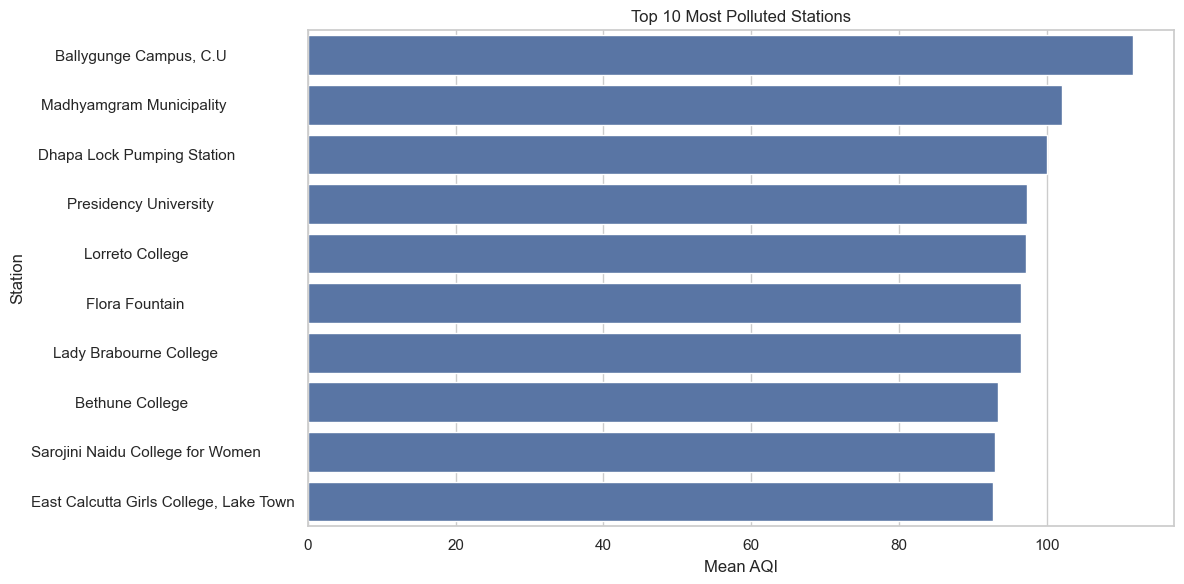

In [50]:
top10 = station_stats.sort_values(
    "mean",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="mean",
    y="station_name"
)

plt.title(
    "Top 10 Most Polluted Stations"
)

plt.xlabel("Mean AQI")

plt.ylabel("Station")

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/top_polluted_stations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Top 10 Cleanest Stations

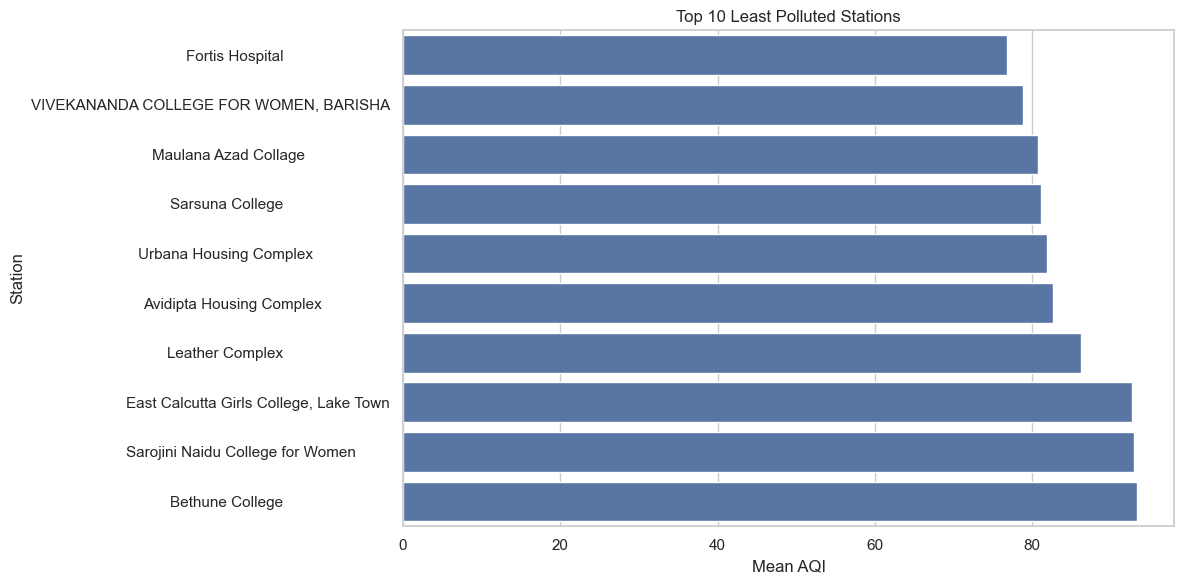

In [51]:
clean10 = station_ranking.tail(10).sort_values(
    "mean",
    ascending=True
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=clean10,
    x="mean",
    y="station_name"
)

plt.title(
    "Top 10 Least Polluted Stations"
)

plt.xlabel("Mean AQI")

plt.ylabel("Station")

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/cleanest_stations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Section E 
# Correlation Analysis
---

## Feature Selection

In [36]:
corr_features = [

    "aqi",

    "pm25",
    "pm10",

    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",

    "precipitation",
    "surface_pressure",

    "cloud_cover",

    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m"
]

## Correlation Matrix

In [37]:
corr_matrix = (
    df[corr_features]
    .corr()
)

corr_matrix.round(3)

,aqi,pm25,pm10,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
aqi,1.000,0.974,0.945,-0.474,-0.123,-0.515,-0.114,0.524,-0.346,-0.247,0.092,-0.303
pm25,0.974,1.000,0.923,-0.468,-0.139,-0.523,-0.119,0.537,-0.363,-0.260,0.106,-0.305
pm10,0.945,0.923,1.000,-0.457,-0.147,-0.521,-0.118,0.524,-0.363,-0.242,0.098,-0.305
temperature_2m,-0.474,-0.468,-0.457,1.000,-0.355,0.575,0.038,-0.608,0.257,0.324,-0.034,0.519
relative_humidity_2m,-0.123,-0.139,-0.147,-0.355,1.000,0.544,0.141,-0.269,0.352,0.002,-0.201,-0.227
dew_point_2m,-0.515,-0.523,-0.521,0.575,0.544,1.000,0.149,-0.759,0.529,0.295,-0.215,0.275
precipitation,-0.114,-0.119,-0.118,0.038,0.141,0.149,1.000,-0.191,0.218,0.124,-0.036,0.190
surface_pressure,0.524,0.537,0.524,-0.608,-0.269,-0.759,-0.191,1.000,-0.533,-0.408,0.116,-0.408
cloud_cover,-0.346,-0.363,-0.363,0.257,0.352,0.529,0.218,-0.533,1.000,0.218,-0.166,0.222
wind_speed_10m,-0.247,-0.260,-0.242,0.324,0.002,0.295,0.124,-0.408,0.218,1.000,-0.026,0.846


In [38]:
corr_matrix.to_csv(
    f"{REPORT_DIR}/correlation_matrix.csv"
)

print("Saved correlation_matrix.csv")

Saved correlation_matrix.csv


## Heatmap

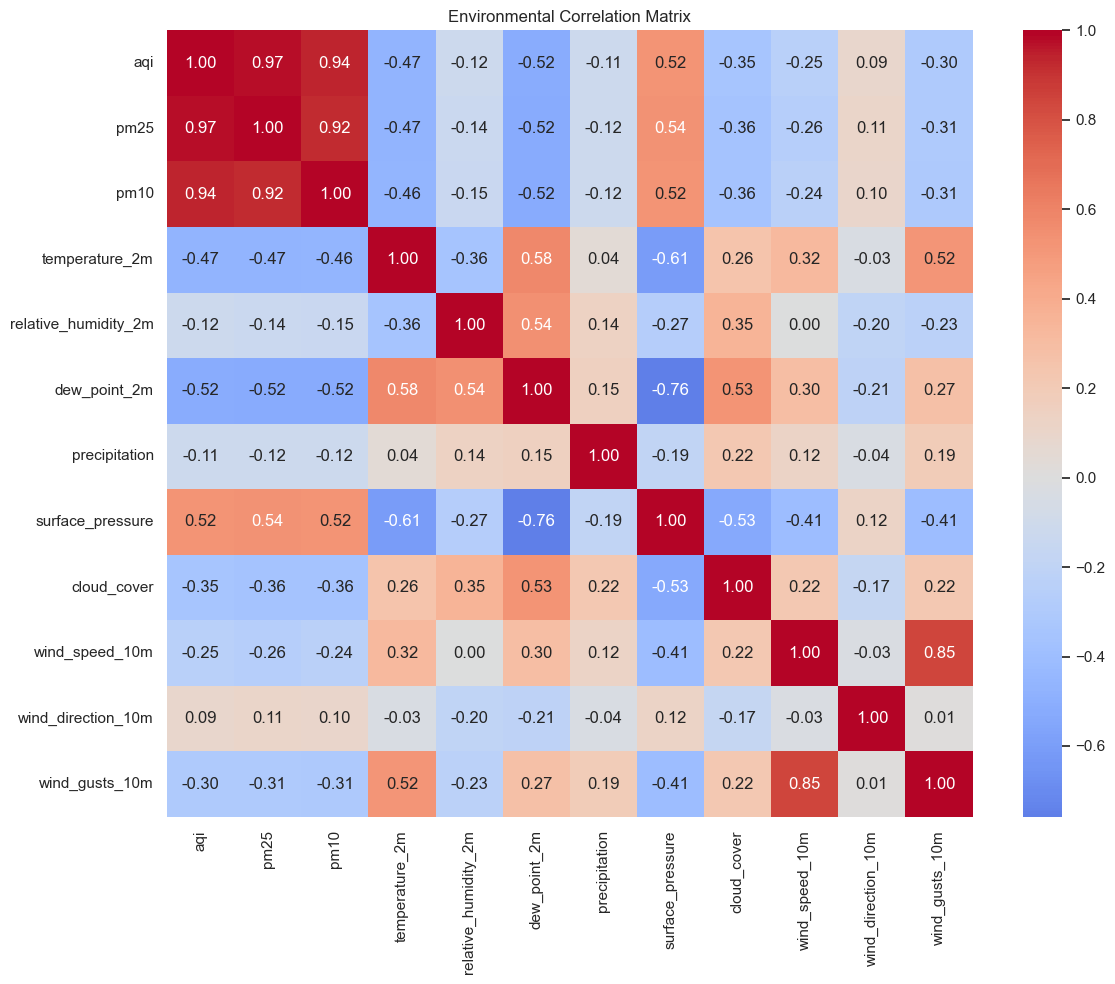

In [39]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title(
    "Environmental Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## AQI Correlation Ranking

In [40]:
aqi_corr = (
    corr_matrix["aqi"]
    .sort_values(
        ascending=False
    )
)

aqi_corr.to_csv(
    f"{REPORT_DIR}/aqi_feature_correlations.csv"
)

# Section F 
# Spatial Hotspot Analysis
---

## Spatial Aggregation

In [41]:
spatial_hotspots = (
    df.groupby(
        [
            "station_name",
            "latitude",
            "longitude"
        ]
    )["aqi"]
    .mean()
    .reset_index()
)

spatial_hotspots.head()

,station_name,latitude,longitude,aqi
0,Avidipta Housing Complex,22.493217,88.398310,82.652859
1,"Ballygunge Campus, C.U",22.526701,88.363210,111.570031
2,Bethune College,22.588510,88.367807,93.368039
3,Dhapa Lock Pumping Station,22.558027,88.409980,99.925539
4,"East Calcutta Girls College, Lake Town",22.601583,88.404556,92.671420


In [42]:
spatial_hotspots.to_csv(
    f"{REPORT_DIR}/spatial_hotspots.csv",
    index=False
)

## Pollution Hotspot Map

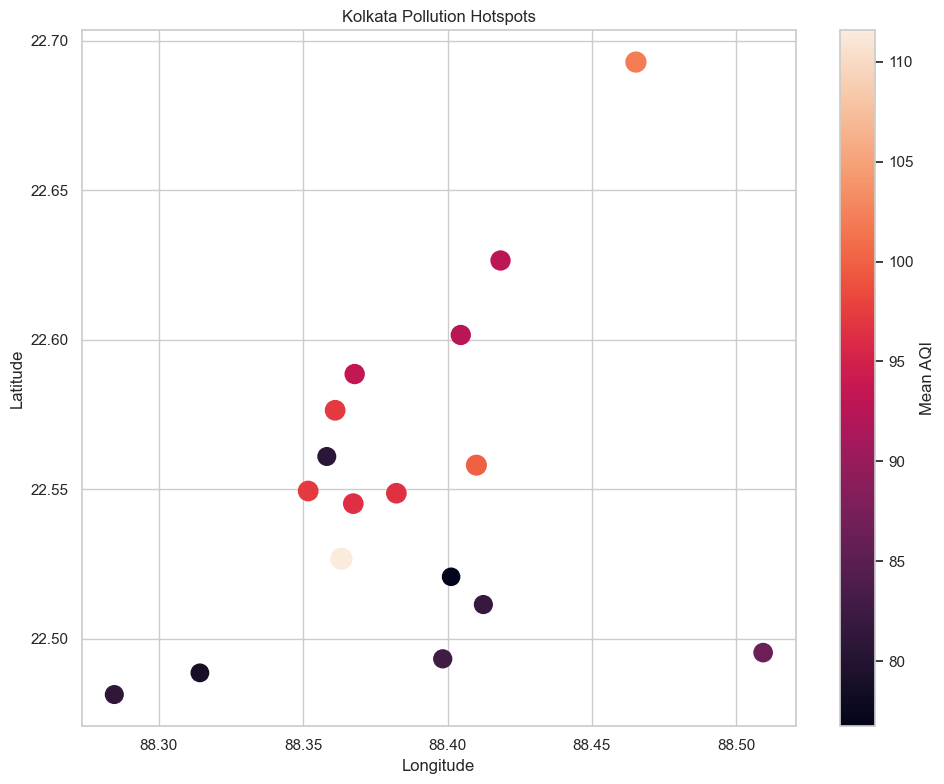

In [43]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(

    spatial_hotspots["longitude"],
    spatial_hotspots["latitude"],

    s=spatial_hotspots["aqi"]*2,

    c=spatial_hotspots["aqi"]
)

plt.colorbar(
    scatter,
    label="Mean AQI"
)

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.title(
    "Kolkata Pollution Hotspots"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/pollution_hotspots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Top Spatial Hotspots

In [44]:
spatial_hotspots.sort_values(
    "aqi",
    ascending=False
).head(10)

,station_name,latitude,longitude,aqi
1,"Ballygunge Campus, C.U",22.526701,88.363210,111.570031
10,Madhyamgram Municipality,22.692911,88.465230,101.966821
3,Dhapa Lock Pumping Station,22.558027,88.409980,99.925539
12,Presidency University,22.576386,88.361045,97.206491
9,Lorreto College,22.549372,88.351710,97.152840
5,Flora Fountain,22.548628,88.382256,96.497770
7,Lady Brabourne College,22.545154,88.367329,96.408662
2,Bethune College,22.588510,88.367807,93.368039
13,Sarojini Naidu College for Women,22.626505,88.418330,92.937726
4,"East Calcutta Girls College, Lake Town",22.601583,88.404556,92.671420


# Section G 
# Environmental Intelligence Summary
---

In [45]:
highest_station = (
    station_ranking.iloc[0]
)

lowest_station = (
    station_ranking.iloc[-1]
)

highest_season = (
    seasonal_stats["mean"]
    .idxmax()
)

lowest_season = (
    seasonal_stats["mean"]
    .idxmin()
)

## Summary Table

## Extract Key Findings

In [46]:
summary = pd.DataFrame({

    "Metric":[

        "Most Polluted Station",
        "Least Polluted Station",

        "Highest Pollution Season",
        "Lowest Pollution Season",

        "Highest AQI",

        "Lowest AQI"
    ],

    "Value":[

        highest_station["station_name"],
        lowest_station["station_name"],

        highest_season,
        lowest_season,

        round(df["aqi"].max(),2),

        round(df["aqi"].min(),2)
    ]
})

summary

,Metric,Value
0,Most Polluted Station,"Ballygunge Campus, C.U"
1,Least Polluted Station,Fortis Hospital
2,Highest Pollution Season,Winter
3,Lowest Pollution Season,Monsoon
4,Highest AQI,697
5,Lowest AQI,1


In [47]:
summary.to_csv(
    f"{REPORT_DIR}/environmental_analytics_summary.csv",
    index=False
)

print(
    "Saved environmental_analytics_summary.csv"
)

Saved environmental_analytics_summary.csv


In [53]:
extreme_aqi = df[
    df["aqi"] > 500
].sort_values("aqi", ascending=False)

print(extreme_aqi[
    [
        "datetime",
        "station_name",
        "aqi",
        "pm25",
        "pm10"
    ]
].head(20))

                  datetime                              station_name  aqi  \
13184  2022-04-27 12:00:00  Sarojini Naidu College for Women          697   
1779   2022-01-23 05:00:00  Leather Complex                           694   
1787   2022-01-23 07:00:00  Leather Complex                           676   
1766   2022-01-23 01:00:00  Leather Complex                           637   
1783   2022-01-23 06:00:00  Leather Complex                           628   
1974   2022-01-25 06:00:00  Leather Complex                           589   
85403  2023-02-28 06:00:00  Leather Complex                           583   
12317  2022-04-22 16:00:00  Sarojini Naidu College for Women          582   
86027  2023-03-02 07:00:00  Leather Complex                           544   
65795  2022-12-24 04:00:00    East Calcutta Girls College, Lake Town  541   
65507  2022-12-23 04:00:00    East Calcutta Girls College, Lake Town  534   
65385  2022-12-22 18:00:00  Avidipta Housing Complex                  533   